In [ ]:
import torch
import torch.nn as nn
import kagglehub
import pandas as pd
import os

In [ ]:
! pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=f6bb1fae26872fd70a286b4c8c217669839562d7916a267849f41e27c88b8833
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [ ]:
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files: ",path)

100%|██████████| 22.0M/22.0M [00:00<00:00, 61.1MB/s]

Extracting files...


Path to dataset files:  /root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


In [ ]:
print(os.listdir(path))

['t10k-images.idx3-ubyte', 't10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'train-labels-idx1-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte', 'train-images-idx3-ubyte']


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(files)

/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1
['t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte']
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-labels-idx1-ubyte
['t10k-labels-idx1-ubyte']
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-images-idx3-ubyte
['t10k-images-idx3-ubyte']
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-labels-idx1-ubyte
['train-labels-idx1-ubyte']
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-images-idx3-ubyte
['train-images-idx3-ubyte']


In [ ]:
import idx2numpy

In [ ]:
#convert ubyte to numpy using idx2numpy

train_images = idx2numpy.convert_from_file(os.path.join(path,'train-images.idx3-ubyte'))
train_labels = idx2numpy.convert_from_file(os.path.join(path,'train-labels.idx1-ubyte'))
test_images = idx2numpy.convert_from_file(os.path.join(path,'t10k-images.idx3-ubyte'))
test_labels  = idx2numpy.convert_from_file(os.path.join(path,'t10k-labels.idx1-ubyte'))

In [ ]:
#check shapes
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)



(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#Preprocessing Step
* covert to float
* reshape the train and test dataset  
* flatten out the train and test features for ANN prediction (-1,784)
* convert to torch



In [ ]:
import numpy as np

In [ ]:
#convert to float
train_images =train_images.astype(np.float32)
test_images =test_images.astype(np.float32)
train_labels = train_labels.astype(np.int64)   #np.long is depricated
test_labels = test_labels.astype(np.int64)     #np.long is depricated

In [ ]:
train_images.dtype

dtype('float32')

In [ ]:
print(train_images[0])

[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.
   18.  18. 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253.
  253. 253. 253. 253. 225. 172. 253. 242. 195.  64.   0.  

In [ ]:
print(train_labels[0])

5


In [ ]:
#reshape the images

train_images = train_images/255.0
test_images = test_images/255.0

In [ ]:
#flatten for ANN
train_images = train_images.reshape(-1,784)
test_images = test_images.reshape(-1,784)

In [ ]:

train_images.shape
test_images.shape

(10000, 784)

In [ ]:
#convert to tensors

train_x = torch.tensor(train_images,dtype=torch.float32)
train_y = torch.tensor(train_labels,dtype=torch.long)
test_x = torch.tensor(test_images,dtype=torch.float32)
test_y = torch.tensor(test_labels,dtype=torch.long )


In [ ]:
test_x.shape

torch.Size([10000, 784])

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader


In [ ]:
#Define our Minibatch Datasets

class MinibatchData(Dataset):
  def __init__(self,features,labels):
      self.features=features
      self.labels =labels

  def __len__(self):
      return self.features.shape[0]    #returns no. of samples training -> 60000

  def __getitem__(self,idx):           #returns data and label of a given index
      return self.features[idx], self.labels[idx]


In [ ]:
train_dataset = MinibatchData(train_x,train_y)
test_dataset = MinibatchData(test_x,test_y)


In [ ]:
len(train_dataset)

60000

In [ ]:
#Dataloader

train_dataloader = DataLoader(train_dataset, batch_size = 32,shuffle =True)
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

In [ ]:
#Define our Model

class ANN(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.network =nn.Sequential(
      nn.Linear(num_features,128),
      nn.ReLU(),
      nn.Linear(128,64),
      nn.ReLU(),
      nn.Linear(64,10)   #softmax added internally by crossentropyloss itself
    )

  def forward(self,X):
    return self.network(X)

In [ ]:
model = ANN(train_x.shape[1])   #no data is passed just the structure of our network

In [ ]:
#Training our Model

epochs = 50 #65 with 0.1 got 0.000101
lr = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=lr)

for batch_features,batch_labels in train_dataloader:
  print(batch_features.shape)
  print(batch_labels.shape)
  break

torch.Size([32, 784])
torch.Size([32])


In [ ]:
# Training Loop
loss =0

for epoch in range(epochs):
  total_loss = 0

  for batch_features, batch_labels in train_dataloader:
    y_pred = model(batch_features)
    loss = criterion(y_pred,batch_labels)

    #clear grads
    optimizer.zero_grad()

    #backwards
    loss.backward()

    #update grads
    optimizer.step()

    total_loss  = total_loss + loss.item()

  print(f"avgloss epoch {epoch+1}= {total_loss/len(train_dataloader)}")



avgloss epoch 1= 1.2076858353535334
avgloss epoch 2= 0.37996154791116715
avgloss epoch 3= 0.30963169742425284
avgloss epoch 4= 0.26859979986449084
avgloss epoch 5= 0.23842634613513947
avgloss epoch 6= 0.21382786987920602
avgloss epoch 7= 0.19302112913429736
avgloss epoch 8= 0.17566715300132832
avgloss epoch 9= 0.1612358388657371
avgloss epoch 10= 0.147905258500576
avgloss epoch 11= 0.13681627928713957
avgloss epoch 12= 0.1267834431221088
avgloss epoch 13= 0.11820472741996249
avgloss epoch 14= 0.11035844405243794
avgloss epoch 15= 0.1034378900791208
avgloss epoch 16= 0.09691572212738295
avgloss epoch 17= 0.09144065787891546
avgloss epoch 18= 0.08609062041764458
avgloss epoch 19= 0.08085117165955405
avgloss epoch 20= 0.07651863340474666
avgloss epoch 21= 0.07241452186281483
avgloss epoch 22= 0.06868788717401525
avgloss epoch 23= 0.06492678000554443
avgloss epoch 24= 0.0618143647527943
avgloss epoch 25= 0.05878514349826922
avgloss epoch 26= 0.05584198983050883
avgloss epoch 27= 0.05318519

In [ ]:
#evaluation
model.eval()
correct =0
total =0
with torch.no_grad():
  for batch_features, batch_labels in test_dataloader:
    y_pred = model(batch_features)
    predicted = torch.argmax(y_pred,dim=1)    #max along the column
    correct += (predicted == batch_labels).sum().item()
    total += batch_labels.size(0)
print(f"Total correct predictions : {(correct/total)*100:.2f}%")



Total correct predictions : 97.91%


In [ ]:
#evaluation
model.eval()
correct =0
total =0
with torch.no_grad():
  for batch_features, batch_labels in train_dataloader:
    y_pred = model(batch_features)
    predicted = torch.argmax(y_pred,dim=1)    #max along the column
    correct += (predicted == batch_labels).sum().item()
    total += batch_labels.size(0)
print(f"Total correct predictions : {(correct/total)*100:.2f}%")



Total correct predictions : 99.67%


<Axes: >

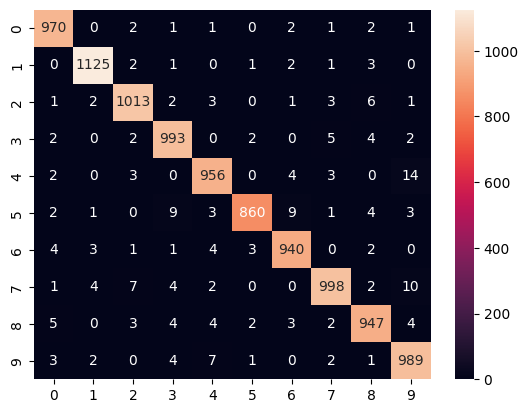

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_dataloader:
        preds = torch.argmax(model(batch_features), dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d')